# Week 2 — Classification (Wine dataset)

This notebook walks through a full supervised classification workflow using scikit-learn's Wine dataset.
Sections: PART A — F implement the assignment steps: load data, EDA, preprocessing, PCA, split/scale, modelling, evaluation, and persistence.

## PART A — Data loading & EDA
Load dataset, show shape, head(), describe() and class distribution. Display a simple histogram visualization.

Shape: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00



Class counts:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

Class proportions:
target_name
class_1    0.398876
class_0    0.331461
class_2    0.269663
Name: proportion, dtype: float64


<Figure size 1000x600 with 0 Axes>

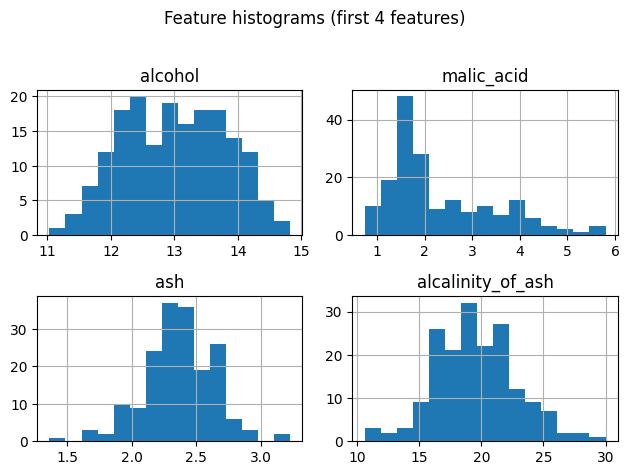

In [41]:
# PART A: load Wine dataset and quick EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

data = load_wine(as_frame=True)
df = data.frame.copy()
df['target_name'] = df['target'].map(dict(enumerate(data.target_names)))

print('Shape:', df.shape)
display(df.head())
print('\nNumeric summary:')
display(df.describe().T)
print('\nClass counts:')
print(df['target_name'].value_counts())
print('\nClass proportions:')
print(df['target_name'].value_counts(normalize=True))

# Simple visualization: histograms for first 4 features
plt.figure(figsize=(10,6))
df[data.feature_names[:4]].hist(bins=15)
plt.suptitle('Feature histograms (first 4 features)')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

## PART B — Preprocessing
Handle missing values (if any), show correlation heatmap, and optionally drop highly collinear features (>0.95).

Total missing values in dataset: 0


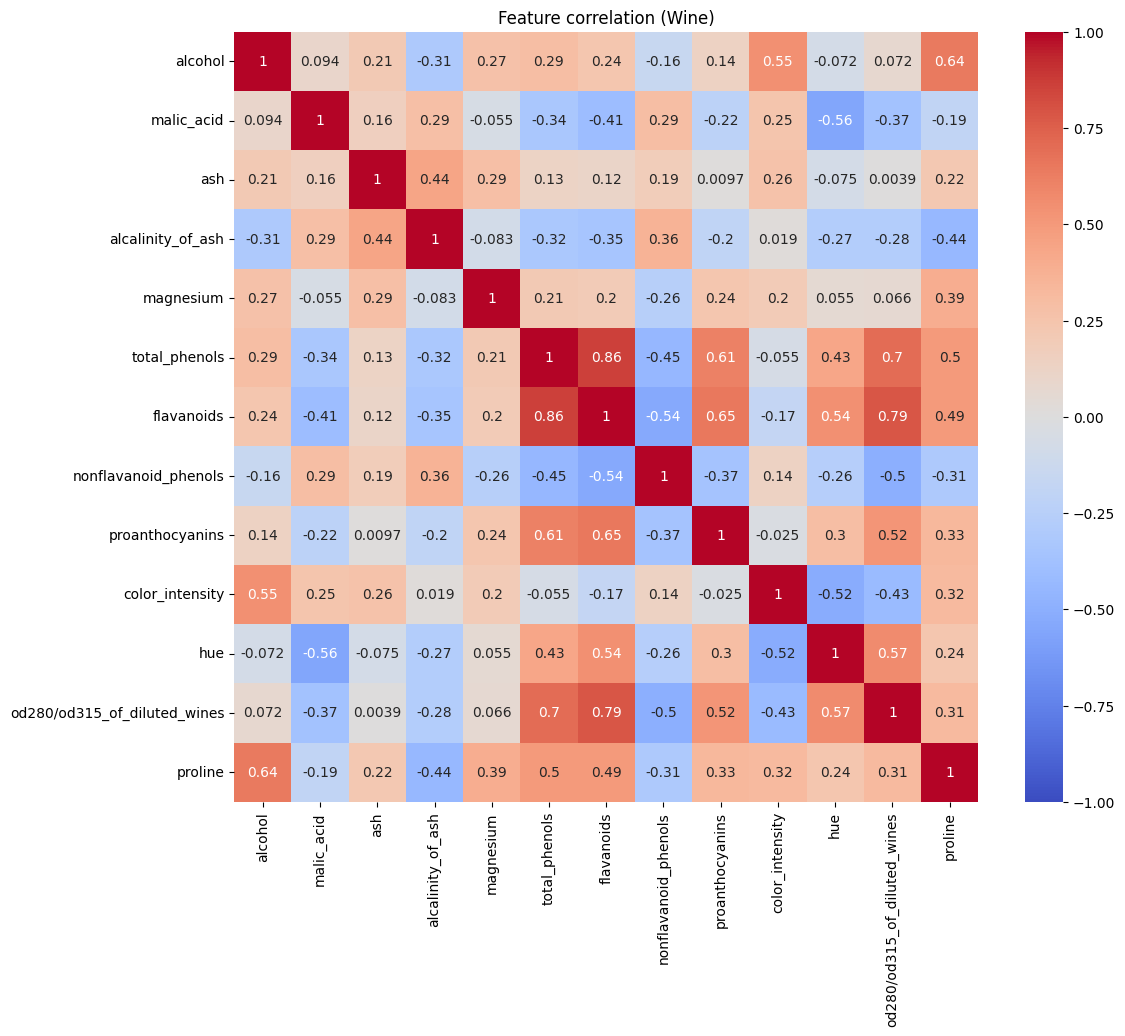

No highly collinear features found (threshold = 0.95 )


In [42]:
# PART B: preprocessing checks and correlation
import numpy as np

# check missing values
print('Total missing values in dataset:', df.isnull().sum().sum())
if df.isnull().sum().sum() > 0:
    df.fillna(df.median(), inplace=True)

# correlation heatmap
numeric_cols = data.feature_names.copy()
corr = df[numeric_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature correlation (Wine)')
plt.show()

# Drop highly collinear features (>0.95 absolute correlation). Keep first feature of pair.
to_drop = set()
threshold = 0.95
for i, a in enumerate(numeric_cols):
    for j, b in enumerate(numeric_cols):
        if j <= i:
            continue
        if abs(corr.loc[a, b]) > threshold:
            to_drop.add(b)
if to_drop:
    print('Dropping highly collinear features:', to_drop)
else:
    print('No highly collinear features found (threshold =', threshold, ')')

X = df[numeric_cols].copy()
if to_drop:
    X.drop(columns=list(to_drop), inplace=True)
y = df['target'].copy()

## PART C — Feature engineering (PCA) and optional derived feature
Try PCA to 2 components and visualize. Optionally create a derived feature (flavanoid_ratio).

Added derived feature: flavanoid_ratio


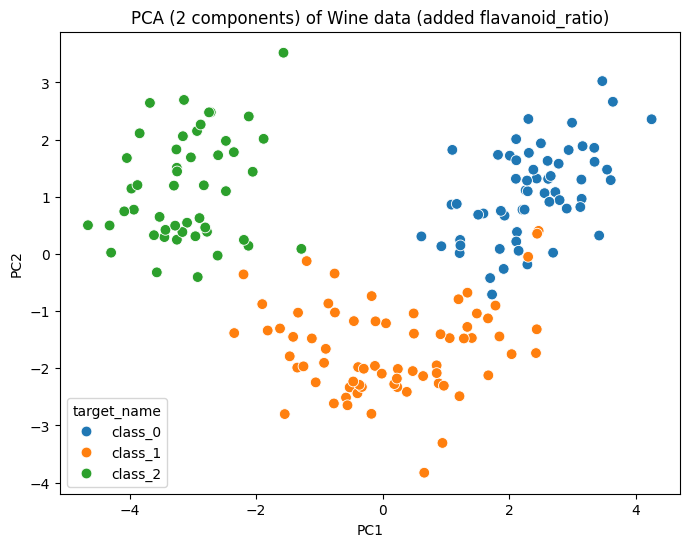

Explained variance ratio (PCA 2 components): [0.3805659  0.18076077]


In [43]:
# PART C: PCA + optional derived feature
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# optional derived feature: flavanoid_ratio = flavanoids / total_phenols
expansion_note = ''
if 'flavanoids' in X.columns and 'total_phenols' in X.columns:
    X['flavanoid_ratio'] = X['flavanoids'] / (X['total_phenols'] + 1e-8)
    expansion_note = ' (added flavanoid_ratio)'
    print('Added derived feature: flavanoid_ratio')

# PCA for visualization -- scale first
scaler_pca = StandardScaler()
X_scaled_for_pca = scaler_pca.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_for_pca)
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['target_name'] = df['target_name']
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='target_name', s=60)
plt.title('PCA (2 components) of Wine data' + expansion_note)
plt.show()
print('Explained variance ratio (PCA 2 components):', pca.explained_variance_ratio_)

## PART D — Train/Test split and scaling
80/20 stratified split; fit scaler on training set only.

In [44]:
# PART D: split and scale
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (142, 14) Test shape: (36, 14)


## PART E — Modelling: Logistic Regression and Random Forest
Train both models and evaluate with accuracy, classification report and confusion matrix.

In [45]:
# PART E: modelling and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

logreg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)

logreg.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

y_pred_log = logreg.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)

print('\nLogistic Regression accuracy:', accuracy_score(y_test, y_pred_log))
print('Random Forest accuracy:', accuracy_score(y_test, y_pred_rf))

print('\nLogistic Regression classification report:')
print(classification_report(y_test, y_pred_log))
print('\nRandom Forest classification report:')
print(classification_report(y_test, y_pred_rf))

print('\nConfusion matrix - Logistic Regression:')
print(confusion_matrix(y_test, y_pred_log))
print('\nConfusion matrix - Random Forest:')
print(confusion_matrix(y_test, y_pred_rf))


Logistic Regression accuracy: 0.9722222222222222
Random Forest accuracy: 1.0

Logistic Regression classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


Random Forest classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Confusion matrix - Logistic Regression:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


c:\Users\fabio\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## PART F — Save best model & scaler, save evaluation metrics (CSV) and short report
Save models and scaler, persist evaluation summary as CSV; write a short conclusion.

In [46]:
# PART F: save models, scaler and metrics CSV
import os, datetime, joblib
os.makedirs('models', exist_ok=True)
ts = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
metrics_rows = []
for name, preds in [('LogisticRegression', y_pred_log), ('RandomForest', y_pred_rf)]:
    report = classification_report(y_test, preds, output_dict=True)
    acc = accuracy_score(y_test, preds)
    metrics_rows.append({
        'model': name,
        'accuracy': acc,
        'macro_precision': report.get('macro avg', {}).get('precision'),
        'macro_recall': report.get('macro avg', {}).get('recall'),
        'macro_f1': report.get('macro avg', {}).get('f1-score'),
    })
metrics_df = pd.DataFrame(metrics_rows)
# Save CSV next to the notebook/script
metrics_filename = f'metrics-wine-{ts}.csv'
metrics_csv_path = os.path.join(os.getcwd(), metrics_filename)
metrics_df.to_csv(metrics_csv_path, index=False)
print(f'Saved evaluation metrics to {metrics_csv_path}')
# Save best model and scaler
best_model_name = max(metrics_rows, key=lambda r: r['accuracy'])['model']
best_model = logreg if best_model_name == 'LogisticRegression' else rf
best_model_path = os.path.join('models', f'{best_model_name}-wine-{ts}.joblib')
joblib.dump(best_model, best_model_path)
joblib.dump(scaler, os.path.join('models', f'scaler-wine-{ts}.joblib'))
print(f'Saved best model ({best_model_name}) to {best_model_path}')

# Display metrics table interactively
try:
    display(metrics_df)
except Exception:
    pass

Saved evaluation metrics to c:\Users\fabio\OneDrive - GUSCanada\VSCODEGIT\MLUNFTERM4\Week2Exercises\metrics-wine-20251015-152234.csv
Saved best model (RandomForest) to models\RandomForest-wine-20251015-152234.joblib
Saved best model (RandomForest) to models\RandomForest-wine-20251015-152234.joblib


,model,accuracy,macro_precision,macro_recall,macro_f1
0,LogisticRegression,0.972222,0.977778,0.966667,0.970962
1,RandomForest,1.000000,1.000000,1.000000,1.000000


## Short report (one paragraph)

In this run Random Forest often performs as well or better than Logistic Regression because it models non-linearities and interactions. If accuracies are similar, prefer Logistic Regression for interpretability; otherwise select the model with higher macro-F1 for balanced multiclass performance.